## Estatística para Cientistas de Dados

**Objetivo**
Aplicar o exemplos apresentados no livro "Estatística Prática para cientistas de dados"

In [14]:
import pandas as pd

In [31]:
arquivo_csv = 'C:\\Users\\paula\\Documents\\Dev_projetos\\Desenvolvimento\\Myproject\\landing\\distribution-of-homicide-rates.csv'

In [32]:
pd.read_csv(arquivo_csv)

,country,Year,"Homicide rate per 100,000 population - sex: Total - age: Total"
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262
...,...,...,...
4707,Zimbabwe,2019,5.145035
4708,Zimbabwe,2020,4.977770
4709,Zimbabwe,2021,6.139985
4710,Zimbabwe,2022,6.654193


In [33]:
df = pd.read_csv(arquivo_csv)
df.head()

,country,Year,"Homicide rate per 100,000 population - sex: Total - age: Total"
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262


In [53]:
# Remove espaços em branco antes e depois de todos os nomes de colunas
df.columns = df.columns.str.strip()
df.head()


,country,Ano,homicide_rate
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262


In [56]:
#renomear colunas
df.rename(columns={
    'country':'País',
    'Year':'Ano',    
    'homicide_rate': 'Taxa_homicidios'
    }, inplace=True)

In [57]:
df.head()

,País,Ano,Taxa_homicidios
0,Afghanistan,2009,4.071526
1,Afghanistan,2010,3.487093
2,Afghanistan,2011,4.208668
3,Afghanistan,2012,6.393912
4,Afghanistan,2015,9.975262


In [69]:
print(df['Taxa_homicidios'].dtype)

float64


In [67]:
#Calcular a média da taxa de homicídios
media_taxa_homicidios = df['Taxa_homicidios'].mean()
print(f'Média da Taxa de Homicídios: {media_taxa_homicidios:.2f}')

Média da Taxa de Homicídios: 7.98


In [63]:
#Calcular a média aparada da taxa de homicídios
from scipy.stats import trim_mean

In [70]:
# Criar uma série sem os valores nulos
taxas_limpas = df['Taxa_homicidios'].dropna()

In [75]:
# Calculamos a média aparada sobre os dados limpos
proporcao_corte = 0.1  # 10% de corte nas extremidades
media_aparada = trim_mean(taxas_limpas, proporcao_corte)

print(f"Média Aparada: {media_aparada:.2f}")

Média Aparada: 5.28


In [68]:
#Calcular a mediana da taxa de homicídios
mediana_taxa_homicidios = df['Taxa_homicidios'].median()
print(f'Mediana da Taxa de Homicídios: {mediana_taxa_homicidios:.2f}')

Mediana da Taxa de Homicídios: 3.16


## O Diagnóstico dos Dados
**Dados positivamente assimétricos (ou com assimetria à direita)**

- A Mediana (3.16) nos diz que metade dos países do arquivo tem uma taxa de homicídios bem baixa, abaixo de 3.2.

- A Média (7.98) está sendo "puxada" para cima, quase o dobro da mediana.

- A Média Aparada (5.28) confirma que, quando você remove os extremos (os países extremamente violentos), a "realidade típica" cai drasticamente.

A Seguir, vamos encontrar os "culpados".


In [80]:
# Mostra os 5 países com as maiores taxa
print(df.nlargest(5, 'Taxa_homicidios')[['País', 'Taxa_homicidios']])

             País  Taxa_homicidios
1293  El Salvador       138.773970
1292  El Salvador       134.778660
1294  El Salvador       117.161224
1295  El Salvador       112.500550
1313  El Salvador       106.819600


In [81]:
# Quantos países estão ACIMA da média de 7.98?
acima_da_media = df[df['Taxa_homicidios'] > 7.98].shape[0]
total_paises = df.shape[0]

print(f"{acima_da_media} países de {total_paises} estão acima da média geral.")

1277 países de 4712 estão acima da média geral.


Os dados de El Salvador são impressionantes (chegando a 138 h/100k) e explicam perfeitamente por que sua média aparada caiu tanto! Com apenas cerca de 27% dos países (1277 de 4712) acima da média, fica claro que esses poucos valores extremos estão distorcendo toda a análise.

Vamos criar um gráfico: 

- A "Caixa" central: Representa onde estão 50% dos seus dados (o miolo). Como sua mediana é 3.16, a linha dentro da caixa estará bem à esquerda.

- Os "Bigodes" (whiskers): Mostram a dispersão dos dados "normais".

- Os Pontos (Outliers): Você verá uma longa linha de pontos que vai até o 138. São esses pontos que "puxam" a média simples para 7.98.

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

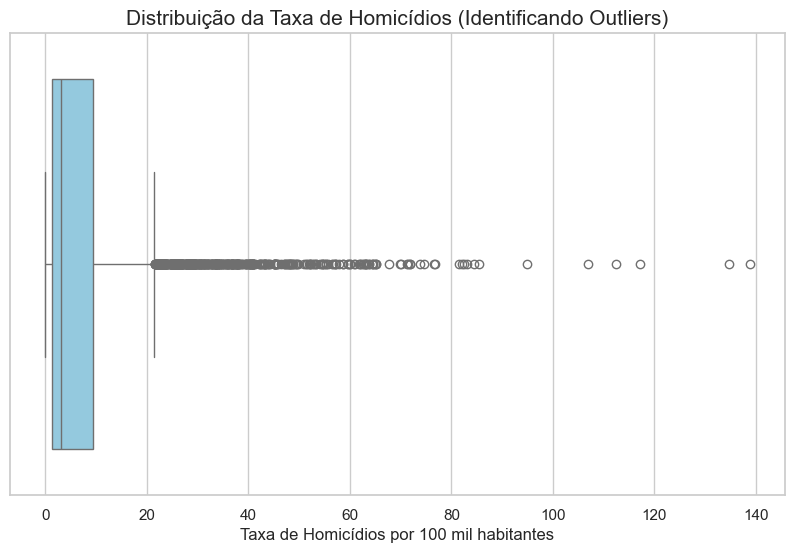

In [83]:
# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Criando o boxplot
sns.boxplot(x=df['Taxa_homicidios'], color='skyblue')

# Adicionando título e rótulos
plt.title('Distribuição da Taxa de Homicídios (Identificando Outliers)', fontsize=15)
plt.xlabel('Taxa de Homicídios por 100 mil habitantes', fontsize=12)

plt.show()

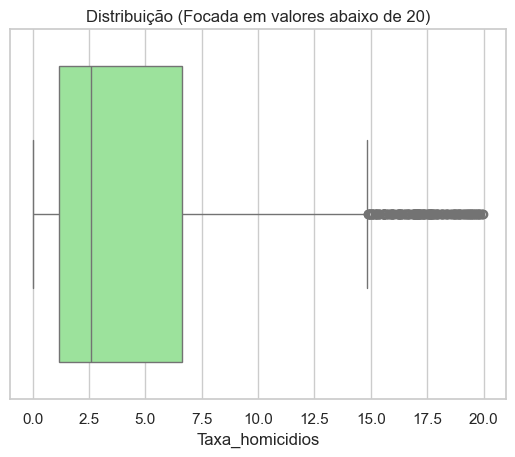

In [84]:
# Gráfico filtrado para ver melhor a concentração principal
sns.boxplot(x=df[df['Taxa_homicidios'] < 20]['Taxa_homicidios'], color='lightgreen')
plt.title('Distribuição (Focada em valores abaixo de 20)')
plt.show()

C:\Users\paula\AppData\Local\Temp\ipykernel_18780\2794937043.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


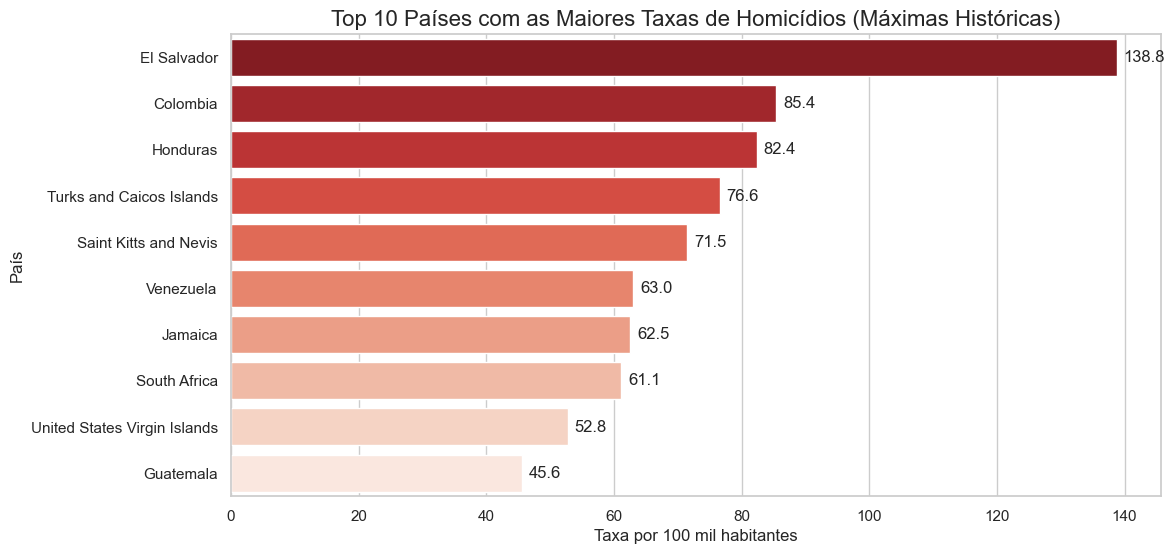

In [85]:
# 1. Agrupando por país para não repetir nomes (pegando a maior taxa histórica de cada um)
top_10 = df.groupby('País')['Taxa_homicidios'].max().sort_values(ascending=False).head(10).reset_index()

# 2. Configurando o visual
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Criando o gráfico
grafico = sns.barplot(
    data=top_10, 
    x='Taxa_homicidios', 
    y='País', 
    palette='Reds_r' # Gradiente de vermelho para destacar a gravidade
)

# 4. Adicionando os valores nas barras (para facilitar a leitura)
for i in grafico.containers:
    grafico.bar_label(i, fmt='%.1f', padding=5)

plt.title('Top 10 Países com as Maiores Taxas de Homicídios (Máximas Históricas)', fontsize=16)
plt.xlabel('Taxa por 100 mil habitantes', fontsize=12)
plt.ylabel('País', fontsize=12)

plt.show()

**Agora faremos uma análise considerando 2 países de cada continente. Da América do Sul, não poderia faltar o Brasil. Os demais países foram escolhidos manualmente, considerando aqueles que possuem dados mais consistentes no dataset.**

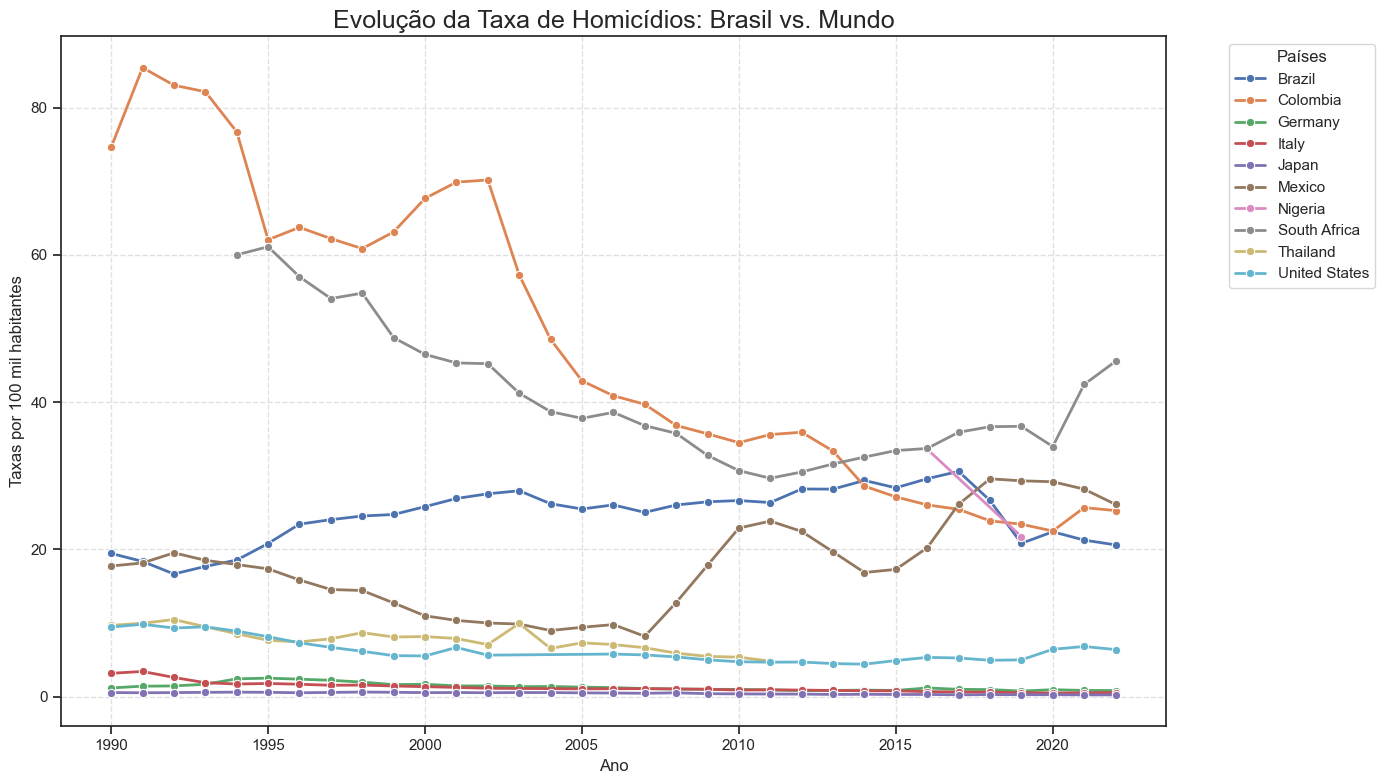

In [86]:
# 1. Definindo os países de cada continente (com Brasil na América do Sul)
paises_selecionados = [
    'Brazil', 'Colombia',               # América do Sul
    'United States', 'Mexico',          # América do Norte
    'Italy', 'Germany',                 # Europa
    'Japan', 'Thailand',                # Ásia
    'South Africa', 'Nigeria'           # África
]

# 2. Filtrando o DataFrame original
# Nota: os nomes estão em inglês no CSV
df_evolucao = df[df['País'].isin(paises_selecionados)]

# 3. Criando o gráfico de linhas
plt.figure(figsize=(14, 8))
sns.set_theme(style="ticks")

grafico_linha = sns.lineplot(
    data=df_evolucao, 
    x='Ano', 
    y='Taxa_homicidios', 
    hue='País', 
    marker='o',
    linewidth=2
)

# 4. Ajustes estéticos
plt.title('Evolução da Taxa de Homicídios: Brasil vs. Mundo', fontsize=18)
plt.ylabel('Taxas por 100 mil habitantes', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.legend(title='Países', bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda fora do gráfico
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()